# How a pile of numbers spreads

A histogram counts how many values fall in each interval. You choose the intervals before you trust the shape.

Ten yields, in percent:

$$
2, 3, 3, 4, 5, 6, 6, 7, 8, 9
$$

Edges at $2, 4, 6, 8, 10$. Every bin is half-open on the right, except the last bin, which includes its right edge:

$$
\begin{aligned}
[2, 4) &\colon 2, 3, 3 &&\rightarrow 3 \\
[4, 6) &\colon 4, 5 &&\rightarrow 2 \\
[6, 8) &\colon 6, 6, 7 &&\rightarrow 3 \\
[8, 10] &\colon 8, 9 &&\rightarrow 2
\end{aligned}
$$

The value $4$ belongs to the second bin, not the first. The value $6$ belongs to the third. The four counts add to $10$, one count per yield.


counts [np.float64(3.0), np.float64(2.0), np.float64(3.0), np.float64(2.0)]


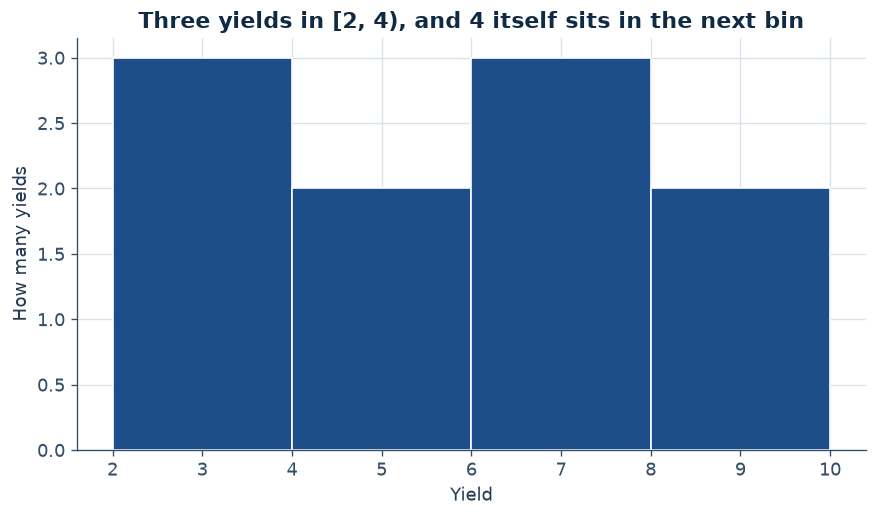

In [1]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Hand bins, then the same count from the chart's rectangles.
values = [2, 3, 3, 4, 5, 6, 6, 7, 8, 9]
edges = [2, 4, 6, 8, 10]

def bin_count(samples, cuts):
    counts = [0] * (len(cuts) - 1)
    for sample in samples:
        for i in range(len(cuts) - 1):
            closed_on_the_right = i == len(cuts) - 2 and sample == cuts[-1]
            if cuts[i] <= sample < cuts[i + 1] or closed_on_the_right:
                counts[i] += 1
                break
    return counts

expected = bin_count(values, edges)
assert expected == [3, 2, 3, 2]
fig, ax = plt.subplots(constrained_layout=True)
counts, drawn_edges, patches = ax.hist(values, bins=edges, color=BLUE, edgecolor="white")
ax.set_xlabel("Yield")
ax.set_ylabel("How many yields")
ax.set_title("Three yields in [2, 4), and 4 itself sits in the next bin")
assert list(counts) == [3, 2, 3, 2]
assert list(drawn_edges) == edges
assert sum(counts) == len(values)
print("counts", list(counts))


## The lab's twenty cells

Every person-day in the North Lab table is one cell. The twenty values are

$$
3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 7, 7, 7, 7, 8
$$

With edges $3, 5, 7, 9$:

$$
\begin{aligned}
[3, 5) &\colon \text{one } 3 \text{ and four } 4\text{s} &&\rightarrow 5 \\
[5, 7) &\colon \text{five } 5\text{s and five } 6\text{s} &&\rightarrow 10 \\
[7, 9] &\colon \text{four } 7\text{s and one } 8 &&\rightarrow 5
\end{aligned}
$$

Half of the cells are $5$ or $6$. The week is not a pile of extremes with a few ordinary days. It is the other way around.


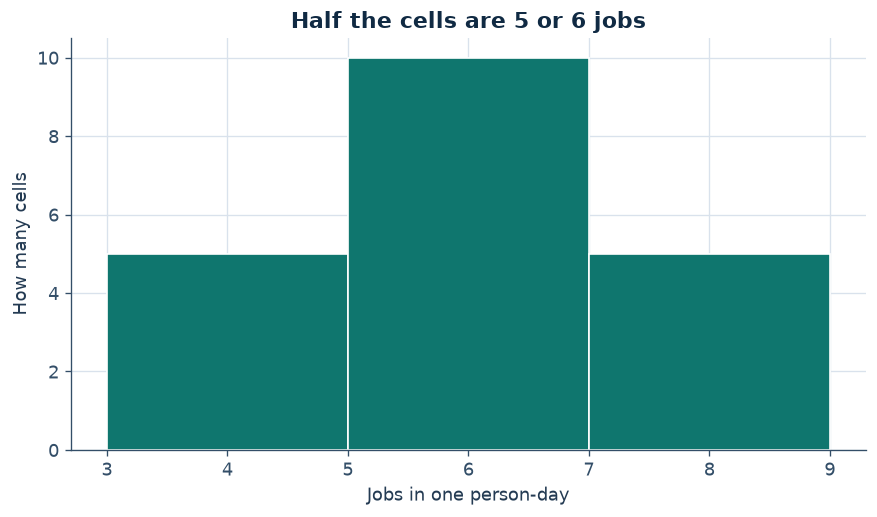

In [2]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Twenty person-days. The middle bin holds half of them.
cells = [4, 5, 5, 6, 7, 6, 6, 7, 7, 8, 3, 4, 4, 5, 4, 5, 5, 6, 6, 7]
assert sorted(cells) == [3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 7, 7, 7, 7, 8]
fig, ax = plt.subplots(constrained_layout=True)
counts, edges, patches = ax.hist(cells, bins=[3, 5, 7, 9], color=GREEN, edgecolor="white")
ax.set_xlabel("Jobs in one person-day")
ax.set_ylabel("How many cells")
ax.set_title("Half the cells are 5 or 6 jobs")
assert list(counts) == [5, 10, 5]
assert sum(counts) == 20


## A pitfall

Ten yields and ten bins do not reveal a finer shape. They mostly reveal the sample again, one bar per point or per tied pair. The eye reads a comb and thinks it is a distribution. For a small sample, choose a few bins you can count by hand, and say the count.

## What to carry forward

A histogram is a table of counts with intervals you chose. State whether the right edge is included. On the yields, the counts are $3, 2, 3, 2$. On the lab cells, $10$ of $20$ sit in $[5, 7)$.


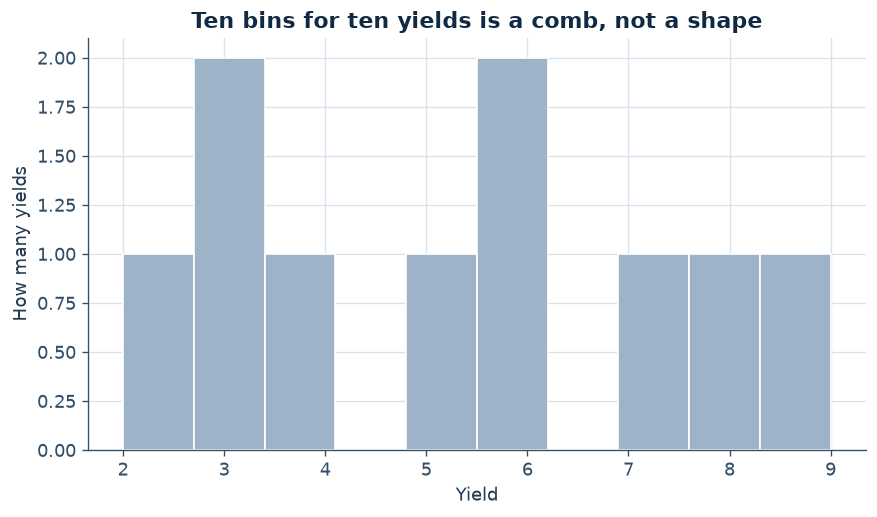

In [3]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Too many bins for ten points: the picture becomes the sample list.
values = [2, 3, 3, 4, 5, 6, 6, 7, 8, 9]
fig, ax = plt.subplots(constrained_layout=True)
counts, edges, patches = ax.hist(values, bins=10, color=GRAY, edgecolor="white")
ax.set_xlabel("Yield")
ax.set_ylabel("How many yields")
ax.set_title("Ten bins for ten yields is a comb, not a shape")
assert len(counts) == 10
assert sum(counts) == 10
assert max(counts) <= 2
